<a href="https://colab.research.google.com/github/afianas/DermaScan/blob/main/Copy_of_Dermascan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
from google.colab import drive, files
import os
import shutil
from PIL import Image
import matplotlib.pyplot as plt

# --- ACTION REQUIRED BY TEAM MEMBER ---
# Create a folder in your Drive called 'Dermascan_Project'
# and put your kaggle.json there.
drive.mount('/content/drive')
BASE_PATH = '/content/drive/MyDrive/Dermascan_Project'
# ---------------------------------------

# Define sub-paths automatically
checkpoint_path = os.path.join(BASE_PATH, 'copy_of_acne_model_best.keras') # Use .keras format
processed_base = 'Organized_Acne_Data'

# Initialize the Checkpoint object
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_best_only=True,
    monitor='val_accuracy',
    verbose=1
)

Mounted at /content/drive


In [3]:
# Setup Kaggle (Uses the file from your Drive instead of manual upload)
kaggle_config = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_config, exist_ok=True)
shutil.copy(os.path.join(BASE_PATH, 'kaggle.json'), os.path.join(kaggle_config, 'kaggle.json'))
os.chmod(os.path.join(kaggle_config, 'kaggle.json'), 0o600)

!kaggle datasets download -d lexuanhieu131297/acne-severity-classification
!unzip -q acne-severity-classification.zip -d acne_raw

Dataset URL: https://www.kaggle.com/datasets/lexuanhieu131297/acne-severity-classification
License(s): unknown
100% 1.04G/1.04G [01:06<00:00, 16.8MB/s]



In [4]:
import os
img_folder = 'acne_raw/Classification/JPEGImages'
if os.path.exists(img_folder):
    print(f"Success! Total images found: {len(os.listdir(img_folder))}")
else:
    print("Error: Could not find the JPEGImages folder. Double-check the unzip path.")

Success! Total images found: 1457


In [5]:
import os

# 1. Check if the zip file exists
if os.path.exists('acne-severity-classification.zip'):
    print("✅ Zip file found.")
else:
    print("❌ Zip file NOT found. Re-run the '!kaggle datasets download' cell.")

# 2. List everything in the 'acne_raw' folder
print("\n--- Folder Structure inside 'acne_raw' ---")
if os.path.exists('acne_raw'):
    for root, dirs, files in os.walk('acne_raw'):
        # Just show the first two levels to keep it clean
        level = root.replace('acne_raw', '').count(os.sep)
        if level < 2:
            print(f"{'  ' * level}{os.path.basename(root)}/")
else:
    print("❌ 'acne_raw' folder does not exist.")

✅ Zip file found.

--- Folder Structure inside 'acne_raw' ---
acne_raw/
  Classification/


In [6]:
import os
from PIL import Image

# 1. Use the BASE_PATH we defined at the start of the program
# This ensures it works for you and your friend's Drive
processed_base = 'Organized_Acne_Data'
classes = ['Mild', 'Moderate', 'Severe']

for cls in classes:
    os.makedirs(os.path.join(processed_base, cls), exist_ok=True)

# 2. Update these paths to be relative to your unzipped Kaggle folder
raw_img_path = 'acne_raw/Classification/JPEGImages'
label_file = 'acne_raw/Classification/NNEW_trainval_0.txt'

def sort_and_resize(source_path, label_path):
    if not os.path.exists(label_path):
        print(f"❌ Error: Label file not found at {label_path}")
        return

    with open(label_path, 'r') as f:
        lines = f.readlines()
        print(f"Processing {len(lines)} images...")

        for line in lines:
            parts = line.split()
            img_name = parts[0]
            label = int(parts[1])

            # Map to 3 clinical levels as per base paper
            if label == 0:
                target_folder = 'Mild'
            elif label in [1, 2]:
                target_folder = 'Moderate'
            else:
                target_folder = 'Severe'

            src = os.path.join(source_path, img_name)
            dest = os.path.join(processed_base, target_folder, img_name)

            if os.path.exists(src):
                with Image.open(src) as img:
                    # Standardizing to 224x224 for MobileNetV2
                    img.convert('RGB').resize((224, 224)).save(dest)
            else:
                # Useful for debugging shared drives
                print(f"⚠️ Warning: {img_name} not found in source.")

# Execute the function
sort_and_resize(raw_img_path, label_file)
print("✅ Sorting and resizing complete!")

Processing 1165 images...
✅ Sorting and resizing complete!


In [7]:
# Add ACNE04 Severe images to your existing Severe folder
acne04_severe_path = '/content/drive/MyDrive/Dermascan_Project/acne_1024/acne3_1024'
dst = 'Organized_Acne_Data/Severe'

count = 0
for img in os.listdir(acne04_severe_path):
    if img.endswith(('.jpg', '.jpeg', '.png')):  # skip the jsonl file
        src = os.path.join(acne04_severe_path, img)
        shutil.copy(src, os.path.join(dst, f'acne04_{img}'))
        count += 1

print(f"✅ Added {count} Severe images")
print(f"Total Severe now: {len(os.listdir(dst))}")

✅ Added 96 Severe images
Total Severe now: 199


In [8]:
# Augment Severe class to reach 400 images
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

augmentor = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

severe_dir = 'Organized_Acne_Data/Severe'
target_count = 400
current_images = [f for f in os.listdir(severe_dir)
                  if f.endswith(('.jpg', '.jpeg', '.png'))]
current_count = len(current_images)
needed = target_count - current_count

print(f"Current Severe: {current_count} | Generating: {needed} more")

generated = 0
idx = 0
while generated < needed:
    img_name = current_images[idx % len(current_images)]
    img_path = os.path.join(severe_dir, img_name)
    img = load_img(img_path, target_size=(224, 224))
    x = img_to_array(img).reshape((1, 224, 224, 3))

    for batch in augmentor.flow(x, batch_size=1):
        save_name = f'sev_aug_{generated}.jpg'
        Image.fromarray(batch[0].astype('uint8')).save(
            os.path.join(severe_dir, save_name))
        generated += 1
        break
    idx += 1

print(f"✅ Done. Total Severe now: {len(os.listdir(severe_dir))}")

Current Severe: 199 | Generating: 201 more
✅ Done. Total Severe now: 400


Run this code to display one random image from your "Severe" folder to confirm the 224×224 resizing worked

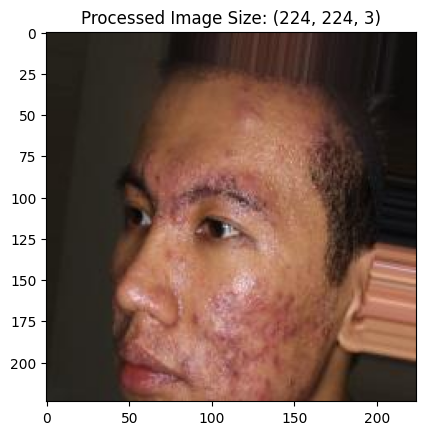

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

folder = 'Organized_Acne_Data/Severe'
first_img = os.listdir(folder)[0]
img = mpimg.imread(os.path.join(folder, first_img))
plt.imshow(img)
plt.title(f"Processed Image Size: {img.shape}")
plt.show()

In [10]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    processed_base,
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = datagen.flow_from_directory(
    processed_base,
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

Found 1170 images belonging to 3 classes.
Found 292 images belonging to 3 classes.


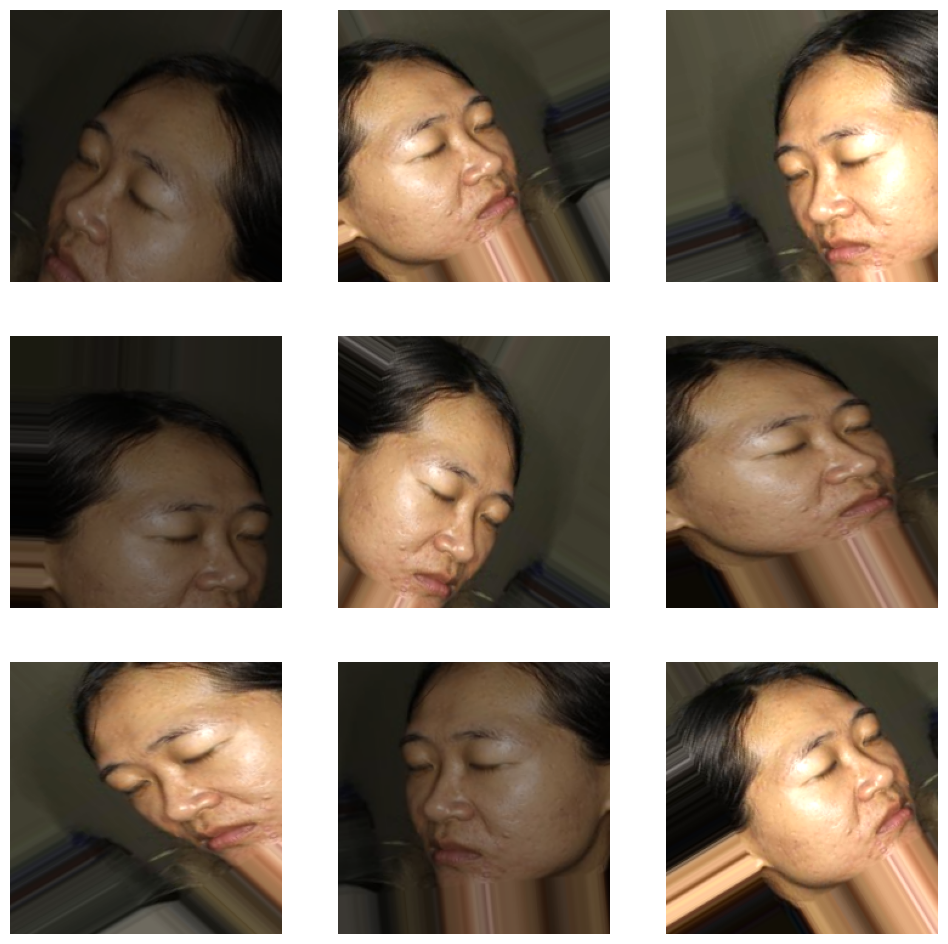

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import matplotlib.pyplot as plt
import os

# 1. Setup the Augmentation Rules (based on the paper)
datagen = ImageDataGenerator(
    rotation_range=40,      # Rotates for different facial orientations [cite: 168]
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,         # Simulates different distances from subject [cite: 169]
    horizontal_flip=True,   # Mirrors for varied perspectives [cite: 168]
    brightness_range=[0.5, 1.5], # Accommodates different lighting [cite: 169]
    fill_mode='nearest'
)

# 2. Pick one image to test
folder = 'Organized_Acne_Data/Moderate'
img_path = os.path.join(folder, os.listdir(folder)[0])
img = load_img(img_path)
x = img_to_array(img).reshape((1,) + img_to_array(img).shape)

# 3. Generate and plot 9 variations
plt.figure(figsize=(12, 12))
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.subplot(3, 3, i + 1)
    plt.imshow(batch[0].astype('uint8'))
    plt.axis('off')
    i += 1
    if i % 9 == 0: break
plt.show()

In [12]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.1890243902439024), 1: np.float64(0.7471264367816092), 2: np.float64(1.21875)}


In [13]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Define MobileNetV2
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # 🔥 change here
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [14]:
# You NEED this line to actually start the training!
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.4165 - loss: 1.4529
Epoch 1: val_accuracy improved from None to 0.63699, saving model to /content/drive/MyDrive/Dermascan_Project/copy_of_acne_model_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dermascan_Project/copy_of_acne_model_best.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 58s 254ms/step - accuracy: 0.4821 - loss: 1.2210 - val_accuracy: 0.6370 - val_loss: 0.7329 - learning_rate: 1.0000e-04
Epoch 2/50
146/147 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6170 - loss: 0.8317
Epoch 2: val_accuracy improved from 0.63699 to 0.67123, saving model to /content/drive/MyDrive/Dermascan_Project/copy_of_acne_model_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Dermascan_Project/copy_of_acne_model_best.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.6231 - loss: 0.8458 - val_accuracy: 0.6712 - val_loss: 0.6612 - learning_rate: 1.0000e-04
Epoch 3/50
145/147 ━━━━━━━━━━━━━━━━━

In [15]:
# --- PHASE 2: Fine-Tuning ---
# Unfreeze the top 30 layers of MobileNetV2
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Recompile with a much lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tuning specific callbacks
early_stop_finetune = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=6,
    restore_best_weights=True
)

reduce_lr_finetune = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)
# New checkpoint for fine-tuned model
checkpoint_finetune = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(BASE_PATH, 'acne_model_finetuned.keras'),
    save_best_only=True,
    monitor='val_accuracy',
    verbose=1
)

history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=[checkpoint_finetune, early_stop, reduce_lr]
)

Epoch 1/50
145/147 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.5367 - loss: 1.2850
Epoch 1: val_accuracy improved from None to 0.72260, saving model to /content/drive/MyDrive/Dermascan_Project/acne_model_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dermascan_Project/acne_model_finetuned.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 54s 201ms/step - accuracy: 0.5906 - loss: 1.0691 - val_accuracy: 0.7226 - val_loss: 0.8603 - learning_rate: 1.0000e-05
Epoch 2/50
146/147 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6673 - loss: 0.8234
Epoch 2: val_accuracy did not improve from 0.72260
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6564 - loss: 0.8564 - val_accuracy: 0.6986 - val_loss: 1.0831 - learning_rate: 1.0000e-05
Epoch 3/50
146/147 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7136 - loss: 0.6842
Epoch 3: val_accuracy did not improve from 0.72260
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7068 - loss: 0.6684 - val_accuracy: 0.6952 - v

In [16]:
# Saves the model to your current directory or Google Drive
model.save('acne_analyzer_model.keras')
print("Model saved successfully!")

Model saved successfully!


Found 292 images belonging to 3 classes.
✅ Best model loaded (72.60% from epoch 32)
37/37 ━━━━━━━━━━━━━━━━━━━━ 14s 184ms/step

Accuracy: 0.76

Classification Report:
              precision    recall  f1-score   support

        Mild       0.61      0.59      0.60        82
    Moderate       0.73      0.72      0.73       130
      Severe       0.94      1.00      0.97        80

    accuracy                           0.76       292
   macro avg       0.76      0.77      0.76       292
weighted avg       0.76      0.76      0.76       292



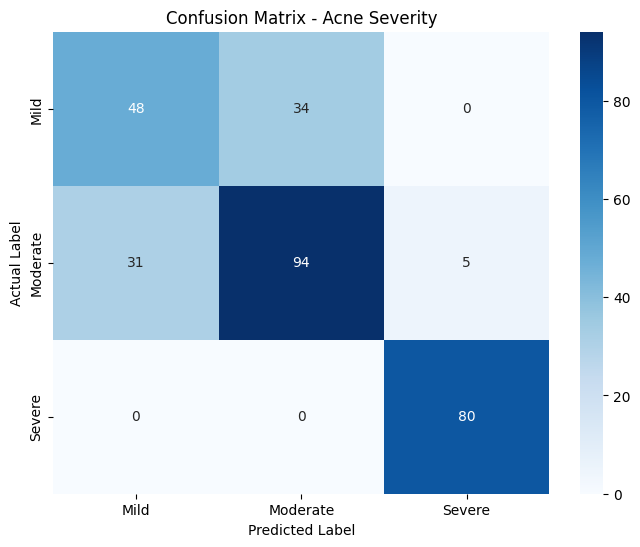

In [21]:
# Rebuild val_gen fresh and evaluate best model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
datagen_eval = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_gen_clean = datagen_eval.flow_from_directory(
    processed_base,
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',
    subset='validation',
    shuffle=False  # critical for correct label alignment
)

model_best = tf.keras.models.load_model(
    os.path.join(BASE_PATH, 'copy_of_acne_model_best.keras')
)
print("✅ Best model loaded (72.60% from epoch 32)")

predictions = model_best.predict(val_gen_clean, steps=len(val_gen_clean), verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = val_gen_clean.classes
class_labels = list(val_gen_clean.class_indices.keys())

print(f"\nAccuracy: {accuracy_score(y_true, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Acne Severity')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

✅ Finetuned model loaded
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 182ms/step

Accuracy: 0.72

Classification Report:
              precision    recall  f1-score   support

        Mild       0.67      0.38      0.48        82
    Moderate       0.64      0.88      0.74       130
      Severe       0.99      0.82      0.90        80

    accuracy                           0.72       292
   macro avg       0.77      0.69      0.71       292
weighted avg       0.74      0.72      0.71       292



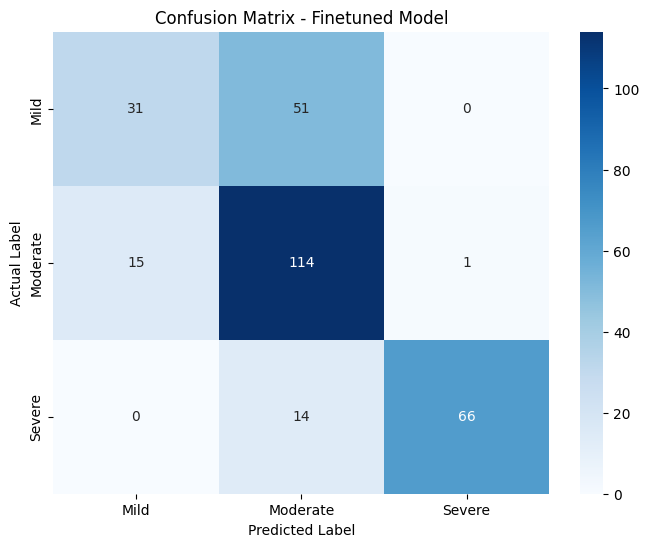

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load FINETUNED model
model_ft = tf.keras.models.load_model(
    os.path.join(BASE_PATH, 'acne_model_finetuned.keras')
)
print("✅ Finetuned model loaded")

# Predict
predictions = model_ft.predict(val_gen_clean, steps=len(val_gen_clean), verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = val_gen_clean.classes

class_labels = list(val_gen_clean.class_indices.keys())

# Accuracy
print(f"\nAccuracy: {accuracy_score(y_true, y_pred):.2f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Finetuned Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [25]:
import tensorflow as tf
import os

# 1. Load your existing .keras model from Google Drive
# Ensure the filename matches what you have in your 'Dermascan_Project' folder
model_path = os.path.join(BASE_PATH, 'copy_of_acne_model_best.keras')

if os.path.exists(model_path):
    print("📂 Loading existing .keras model...")
    model = tf.keras.models.load_model(model_path)

    # 2. Initialize the TFLite Converter
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    # 3. Apply Optimization (Reduces file size for Android)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    # 4. Convert and Save
    tflite_model = converter.convert()
    tflite_path = os.path.join(BASE_PATH, 'copy_of_acne_model_best.tflite')

    with open(tflite_path, "wb") as f:
        f.write(tflite_model)

    print(f"✅ Success! Your Android-ready model is at: {tflite_path}")

else:
    print(f"❌ Error: Could not find {model_path}. Please check your BASE_PATH.")

📂 Loading existing .keras model...
Saved artifact at '/tmp/tmp71r4_rob'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  135063735778576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135063735777424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135063735776464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135063735776848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135063735776656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135063735776080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135063735775888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135063735777232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135063735776272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135063735775312: TensorSpec(shape=(), dtype=tf.r